In [1]:
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model
from xgboost import XGBRegressor

# ini agar google colab tersambung dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv(
    '/content/drive/MyDrive/Dataset/prediksi_harga_laptop_XGBoost_Regression/laptop_price.csv',
    encoding='latin1'
)
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


# Data Understanding (Pengenalan Dataset)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [4]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [5]:
df['Ram'].value_counts()

,count
Ram,
8GB,619
4GB,375
16GB,200
6GB,41
12GB,25
2GB,22
32GB,17
24GB,3
64GB,1


# EDA (Exploratory Data Analysis)

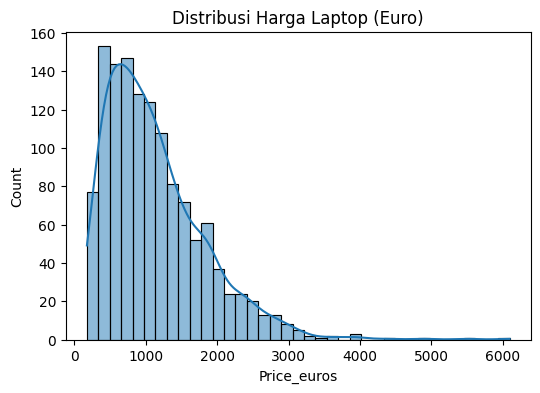

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price_euros"], kde=True)
plt.title("Distribusi Harga Laptop (Euro)")
plt.show()

# Cleaning Data

In [7]:
df.isna().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Cek Outlier (IQR)

In [9]:
Q1 = df["Price_euros"].quantile(0.25)
Q3 = df["Price_euros"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Price_euros"] < lower) | (df["Price_euros"] > upper)]
print("Jumlah outlier:", len(outliers))

Jumlah outlier: 29


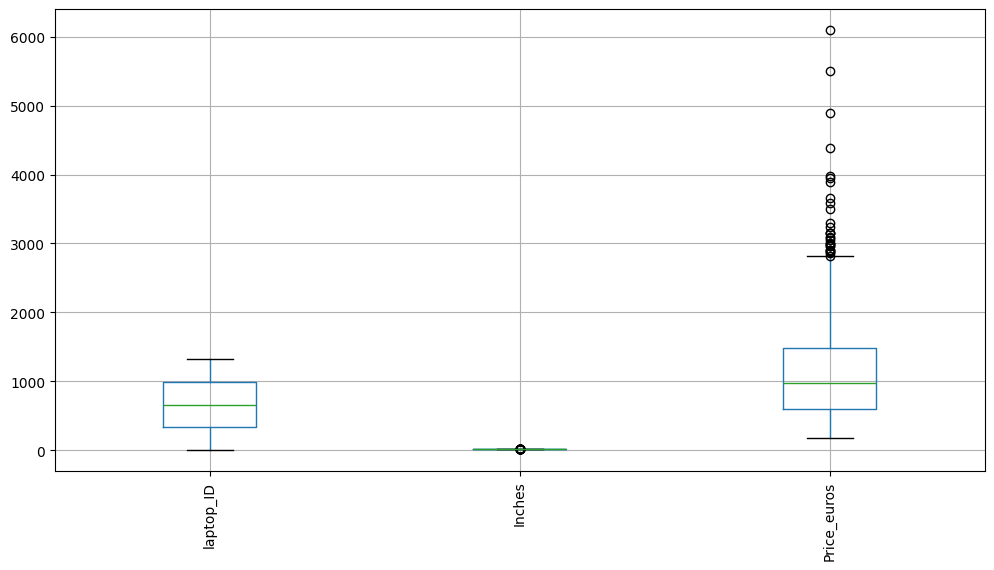

In [10]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(12,6))
df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.show()

# Pisahkan fitur dan label

In [11]:
X = df.drop(columns=["laptop_ID", "Product", "ScreenResolution", "Price_euros"])
y = df["Price_euros"]

In [12]:
X.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg


# Preprocessing

In [13]:
# Pastikan X fresh dari awal (jalankan ulang cell load data)
# Lalu gunakan ini:

X['Ram'] = X['Ram'].str.replace('GB', '', regex=False).astype(int)
X['Weight'] = X['Weight'].str.replace('kg', '', regex=False).astype(float)

print(X['Ram'].head())
print(X['Weight'].head())

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64
0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64


In [14]:
X.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37


In [15]:
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

print("Numerical:", num_features)
print("Categorical:", cat_features)

Numerical: Index(['Inches', 'Ram', 'Weight'], dtype='object')
Categorical: Index(['Company', 'TypeName', 'Cpu', 'Memory', 'Gpu', 'OpSys'], dtype='object')


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_features)
    ]
)

# TRAIN TEST SPLIT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model XGBoost

In [18]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    # Intinya: reg = ini tugas regresi (prediksi angka), squarederror = cara ngukur kesalahannya
    # jadi agar memberi hukuman lebih besar jika salah prediksi nya besar
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])

In [19]:
# param_grid = {
#     "model__n_estimators": [100, 200], # berapa banyak pohon
#     "model__max_depth": [3, 5, 7], # kedalaman pohon
#     "model__learning_rate": [0.05, 0.1], # Seberapa besar koreksi yang dilakukan setiap pohon ($\eta$).
#     "model__subsample": [0.8, 1.0], # Berapa persen data dipakai tiap pohon
#     "model__colsample_bytree": [0.8, 1.0] # Berapa persen kolom dipakai tiap pohon
# }

# grid = GridSearchCV(
#     model,
#     param_grid,
#     cv=3,
#     scoring="neg_mean_squared_error",  # cara ukur kesalahan model, makin kecil makin bagus
#     n_jobs=-1 # pakai semua CPU
# )

# # cv=3 artinya data dibagi 3, dicoba bergantian:
# # Giliran 1: [TEST][train][train]
# # Giliran 2: [train][TEST][train]
# # Giliran 3: [train][train][TEST]
# # Hasil = rata-rata ketiganya

# grid.fit(X_train, y_train)

# print("Best params:", grid.best_params_)
# best_model = grid.best_estimator_

In [20]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],   # Minimum data di tiap daun pohon - cegah overfitting
    "model__gamma": [0, 0.1, 0.2, 0.5],     # Ambang batas untuk membagi cabang pohon - cegah pohon tumbuh berlebihan
    "model__reg_alpha": [0, 0.1, 0.5],      # Regulasi L1 (mendorong bobot ke nol)
    "model__reg_lambda": [1, 1.5, 2]        # Regulasi L2 (mengecilkan bobot besar)
}

# PKalau GridSearch = mencoba SEMUA kombinasi (bisa ribuan!)
# RandomizedSearch = hanya mencoba 50 kombinasi ACAK → jauh lebih cepat
tuning = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,          # coba 50 kombinasi acak
    cv=5,
    scoring="neg_mean_squared_error", # MSE yaitu cara mengukur seberapa salah prediksi model
    # Jadi dengan neg_mean_squared_error, sklearn tinggal mencari nilai terbesar (yang paling mendekati 0), dan itu otomatis sama dengan mencari MSE terkecil.
    verbose=1,
    random_state=42,
    n_jobs=-1 # pakai semua core CPU supaya lebih cepat
)

tuning.fit(X_train, y_train)
print("Best params:", tuning.best_params_)
best_model = tuning.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': 0.7, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}


In [21]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

def eval_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred) # Menghitung MAE:Mean Absolute Error/ rata-rata selisih antara prediksi dan nilai asli
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # Menghitung RMSE = Root Mean Squared Error
                            # Bedanya dengan MAE: error dipangkatkan dulu, error besar dihukum lebih berat
                            # Gunakan RMSE kalau kesalahan besar sangat berbahaya dan Error besar harus dihindari
    r2 = r2_score(y_true, y_pred) # Menghitung R² = Koefisien Determinasi
                  # R² menunjukkan berapa persen variasi data dijelaskan oleh model. Contoh: R² = 0.88 Artinya: 88% harga laptop bisa dijelaskan oleh model
    print(f"{name} MAE: {mae:,.0f}")
    print(f"{name} RMSE: {rmse:,.0f}")
    print(f"{name} R2: {r2:.4f}")

eval_model(y_train, y_train_pred, "Train")
eval_model(y_test, y_test_pred, "Test")

Train MAE: 101
Train RMSE: 136
Train R2: 0.9616
Test MAE: 166
Test RMSE: 274
Test R2: 0.8519


In [22]:
# Train MAE: 2,579,122  # rata-rata meleset Rp 2,5 juta saat latihan
# Test MAE: 3,455,121   # rata-rata meleset Rp 3,4 juta saat test

# Train RMSE: 3,565,238 #
# Test RMSE: 5,807,434  #

# Train R2: 0.9316      # model menangkap 93% pola data latihan
# Test R2: 0.8273       # model menangkap 82% pola data baru




Feature Importance adalah cara untuk tahu "fitur mana yang paling berpengaruh saat prediksi

In [23]:
xgb_model = best_model.named_steps["model"] # artinya "ambil khusus bagian XGBoost saja" dari pipeline
importances = xgb_model.feature_importances_  # artinya "minta XGBoost kasih tahu skor tiap fitur"

feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
# named_steps["preprocess"] = ambil bagian **"preprocess"**
# get_feature_names_out() = ambil nama semua fitur **setelah** diproses ColumnTransformer, karena setelah di proses nama semua fitur berubah

# Gabungkan Jadi Tabel
fi = pd.DataFrame({
    "feature": feature_names, # nama fitur
    "importance": importances # skor pentinya
}).sort_values(by="importance", ascending=False) # ini untuk mengurutkan dari yang terpenting

fi.head(10)

,feature,importance
1,num__Ram,0.435788
5,cat__Cpu,0.139377
7,cat__Gpu,0.087342
8,cat__OpSys,0.086466
4,cat__TypeName,0.062697
0,num__Inches,0.059291
2,num__Weight,0.051308
6,cat__Memory,0.048737
3,cat__Company,0.028993


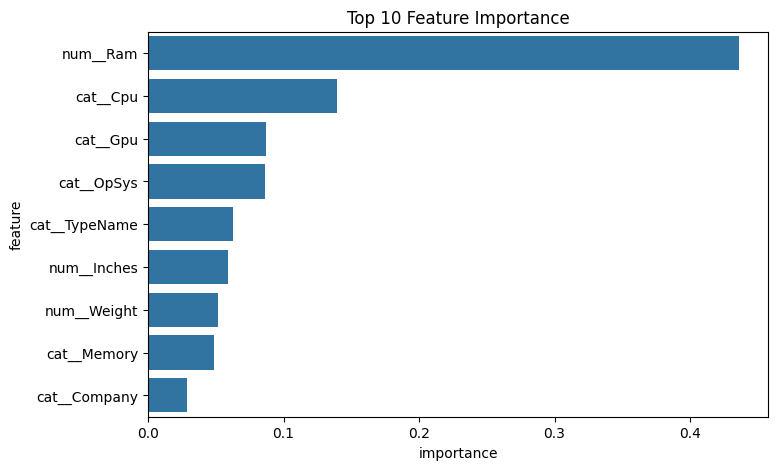

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=fi.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

SHAP adalah metode untuk menjelaskan output dari model machine learning. Ia memberi tahu kita seberapa besar pengaruh setiap fitur (kolom) terhadap hasil prediksi akhir. Jadi kayak kenapa hasil prediksinya segini.

SHAP menjelaskan kontribusi tiap fitur untuk setiap prediksi!

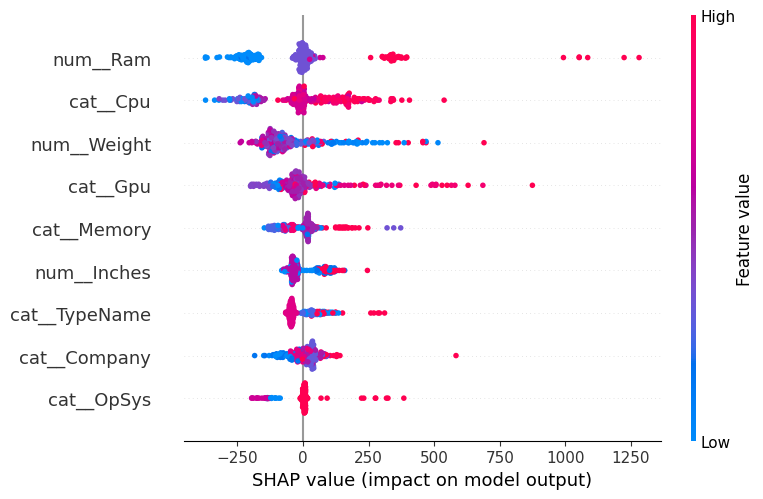

In [25]:
import shap

# Ambil model XGBoost dari pipeline
xgb_model = best_model.named_steps["model"]

# Ambil data test yang sudah dipreprocess
X_test_transformed = best_model.named_steps["preprocess"].transform(X_test)

# Buat explainer
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_transformed)

# Visualisasi 1 - Fitur paling berpengaruh secara keseluruhan
shap.summary_plot(shap_values, feature_names=feature_names)

Prediksi

In [26]:
import requests

laptop_baru = pd.DataFrame([{
    "Company"   : "Apple",
    "TypeName"  : "Ultrabook",
    "Inches"    : 13.3,
    "Cpu"       : "Intel Core i5 2.3GHz",
    "Ram"       : 24,
    "Memory"    : "256GB SSD",
    "Gpu"       : "Intel Iris Plus Graphics 640",
    "OpSys"     : "macOS",
    "Weight"    : 1.37
}])

# Prediksi (hasil dalam Euro)
hasil = best_model.predict(laptop_baru)
harga_euro = hasil[0]

# Ambil kurs EUR -> IDR realtime
response = requests.get("https://api.frankfurter.app/latest?from=EUR&to=IDR")
data = response.json()
kurs = data["rates"]["IDR"]

# Konversi
harga_rupiah = harga_euro * kurs

print(f"Kurs saat ini : €1 = Rp {kurs:,.2f}")
print(f"Prediksi Harga (EUR) : €{harga_euro:,.3f}")
print(f"Prediksi Harga (IDR) : Rp {harga_rupiah:,.2f}")

Kurs saat ini : €1 = Rp 20,202.65
Prediksi Harga (EUR) : €2,261.101
Prediksi Harga (IDR) : Rp 45,680,228.00


Simpan model

In [30]:
import joblib

joblib.dump(best_model,"model_xgb_laptop.pkl")

['model_xgb_laptop.pkl']

In [31]:
from google.colab import files

# perintah untuk download model
files.download("model_xgb_laptop.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import matplotlib
import sklearn
import sys


print("pandas   :", pd.__version__)
print("numpy    :", np.__version__)
print("matplotlib :", matplotlib.__version__)
print("seaborn    :", sns.__version__)
print("joblib   :", joblib.__version__)
print("sklearn   :", sklearn.__version__)
print("python   :", sys.version)

pandas   : 2.2.2
numpy    : 2.0.2
matplotlib : 3.10.0
seaborn    : 0.13.2
joblib   : 1.5.3
sklearn   : 1.6.1
python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
